In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

### Data Cleaning

In [2]:
spam_example = None
ham_example = None

for line in open('data/SMSSpamCollection'):
    if line.startswith('spam') and spam_example is None:
        spam_example = line
    elif line.startswith('ham') and ham_example is None:
        ham_example = line
    
    if spam_example and ham_example:
        break

print(f"Spam example: {spam_example}")
print(f"Non-spam (ham) example: {ham_example}")

Spam example: spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Non-spam (ham) example: ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...



In [3]:
all_labels = [line.split('\t')[0] for line in open('data/SMSSpamCollection')]

spam_count = all_labels.count('spam')
ham_count = all_labels.count('ham')

print(f"Number of spam messages: {spam_count}")
print(f"Number of non-spam (ham) messages: {ham_count}")

Number of spam messages: 747
Number of non-spam (ham) messages: 4827


In [4]:
import csv

sequences = []
labels = []

# Load and parse the data
with open('data/SMSSpamCollection', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter='\t')
    for row in reader:
        if len(row) == 2:
            label_str, text = row
            labels.append(1 if label_str == 'spam' else 0)
            sequences.append(text)

# Build the vocabulary (stoi and itos)
all_text = "".join(sequences)
unique_chars = sorted(list(set(all_text)))

# Reserve index 0 for padding
stoi = {char: i + 1 for i, char in enumerate(unique_chars)}
stoi['<pad>'] = 0

itos = {i: char for char, i in stoi.items()}

# Convert sequences to lists of character IDs
encoded_sequences = [[stoi[char] for char in seq] for seq in sequences]

print(f"Vocabulary size: {len(stoi)}")
print(f"Example encoded sequence: {encoded_sequences[0][:10]}...")
print(f"Example label: {labels[0]}")

Vocabulary size: 119
Example encoded sequence: [42, 81, 3, 87, 80, 86, 75, 78, 3, 76]...
Example label: 0


#### Class Imbalance

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

# Indices for the split
indices = np.arange(len(encoded_sequences))

# Perform  Split 
train_idx, rem_idx = train_test_split(indices, test_size=0.4, random_state=42)
val_idx, test_idx = train_test_split(rem_idx, test_size=0.5, random_state=42)

# Extract
train_x = [encoded_sequences[i] for i in train_idx]
train_y = [labels[i] for i in train_idx]
val_x = [encoded_sequences[i] for i in val_idx]
val_y = [labels[i] for i in val_idx]
test_x = [encoded_sequences[i] for i in test_idx]
test_y = [labels[i] for i in test_idx]

# Oversample only training set to fix data lekeage problem
train_spam_samples = [sample for idx, sample in enumerate(train_x) if train_y[idx] == 1]

# Duplicate the spam samples 6 times and append to the existing training lists
train_x.extend(train_spam_samples * 6)
train_y.extend([1] * (len(train_spam_samples) * 6))

print(f"Final Train Size: {len(train_x)} (Ham: {train_y.count(0)}, Spam: {train_y.count(1)})")
print(f"Pure Val Size: {len(val_x)}")
print(f"Pure Test Size: {len(test_x)}")

Final Train Size: 6079 (Ham: 2887, Spam: 3192)
Pure Val Size: 1114
Pure Test Size: 1115


In [6]:
class MyDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = [torch.tensor(s) for s in sequences]
        self.labels = torch.tensor(labels)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def collate_sequences(batch):
    """
    batch is a list of tuples: [(sequence1, label1), (sequence2, label2), ...]
    """
    # Unzip batch into two lists
    sequences, labels = zip(*batch)
    
    # Pad  sequences
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)
    
    # Stack labels into a single tensor
    labels = torch.stack(labels)
    
    return padded_sequences, labels

train_loader = DataLoader(dataset=MyDataset(train_x, train_y), batch_size=32, shuffle=True, collate_fn=collate_sequences)
val_loader = DataLoader(dataset=MyDataset(val_x, val_y), batch_size=32, shuffle=False, collate_fn=collate_sequences)
test_loader = DataLoader(dataset=MyDataset(test_x, test_y), batch_size=32, shuffle=False, collate_fn=collate_sequences)

In [7]:
for i, (sequences, labels) in enumerate(train_loader):
    if i >= 10: 
        break
    
    # Max length is the second dimension of our padded tensor
    max_len = sequences.shape[1]
    
    # Count how many zeros are in the tensor
    num_padding = (sequences == 0).sum().item()
    
    print(f"Batch {i+1}: Max Length = {max_len}, Total Pad Tokens = {num_padding}")

Batch 1: Max Length = 263, Total Pad Tokens = 4517
Batch 2: Max Length = 160, Total Pad Tokens = 1925
Batch 3: Max Length = 161, Total Pad Tokens = 1872
Batch 4: Max Length = 163, Total Pad Tokens = 1845
Batch 5: Max Length = 161, Total Pad Tokens = 2278
Batch 6: Max Length = 161, Total Pad Tokens = 1990
Batch 7: Max Length = 220, Total Pad Tokens = 3321
Batch 8: Max Length = 181, Total Pad Tokens = 2638
Batch 9: Max Length = 159, Total Pad Tokens = 1716
Batch 10: Max Length = 172, Total Pad Tokens = 2108


### Model Building

In [9]:
class SpamRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_classes=2):
        super(SpamRNN, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.ident = torch.eye(vocab_size) # ONe hot identity matrix
        self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        x = self.ident[x].to(x.device)
        out, (hn, cn) = self.rnn(x)
        max_pool = torch.max(out, dim=1)[0]
        mean_pool = torch.mean(out, dim=1)
        cat = torch.cat([max_pool, mean_pool], dim=1)
        return self.fc(cat)

model = SpamRNN(vocab_size=119, hidden_size=64)
print(model)

SpamRNN(
  (rnn): LSTM(119, 64, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


### Training

In [10]:
def get_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for sequences, labels in data_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            output = model(sequences)
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += labels.shape[0]
            
    return correct / total

Epoch 1: Loss 0.3584 | Train Acc 0.9337 | Val Acc 0.9686
Epoch 2: Loss 0.2130 | Train Acc 0.9472 | Val Acc 0.9677
Epoch 3: Loss 0.2019 | Train Acc 0.9400 | Val Acc 0.9758
Epoch 4: Loss 0.4039 | Train Acc 0.9460 | Val Acc 0.9704
Epoch 5: Loss 0.1789 | Train Acc 0.9518 | Val Acc 0.9677
Epoch 6: Loss 0.1212 | Train Acc 0.9650 | Val Acc 0.9820
Epoch 7: Loss 0.0981 | Train Acc 0.9752 | Val Acc 0.9856
Epoch 8: Loss 0.0859 | Train Acc 0.9757 | Val Acc 0.9758
Epoch 9: Loss 0.0726 | Train Acc 0.9755 | Val Acc 0.9713
Epoch 10: Loss 0.0611 | Train Acc 0.9809 | Val Acc 0.9776
Epoch 11: Loss 0.0504 | Train Acc 0.9840 | Val Acc 0.9811
Epoch 12: Loss 0.0468 | Train Acc 0.9886 | Val Acc 0.9874
Epoch 13: Loss 0.0364 | Train Acc 0.9908 | Val Acc 0.9811
Epoch 14: Loss 0.0374 | Train Acc 0.9923 | Val Acc 0.9856
Epoch 15: Loss 0.0251 | Train Acc 0.9942 | Val Acc 0.9856
Epoch 16: Loss 0.0235 | Train Acc 0.9957 | Val Acc 0.9865
Epoch 17: Loss 0.0179 | Train Acc 0.9901 | Val Acc 0.9713
Epoch 18: Loss 0.0173 |

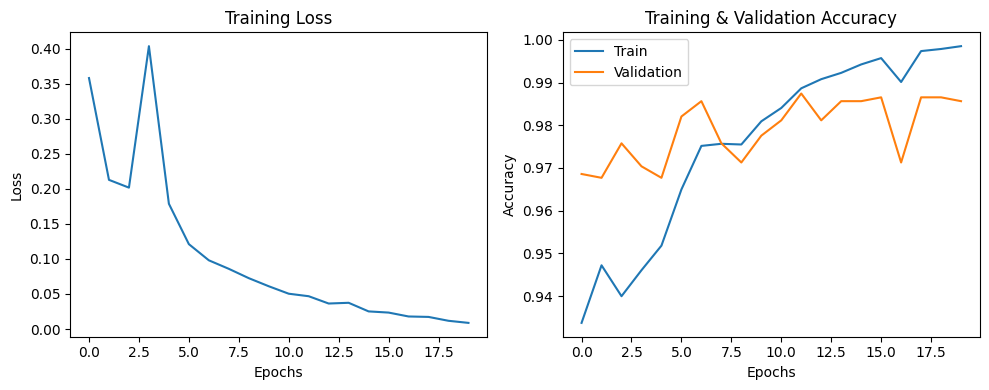

([0.35839293308948217,
  0.21300809073605034,
  0.20189260383577723,
  0.4039325359130376,
  0.17887834251711243,
  0.12121396166713615,
  0.09811703308338397,
  0.08594253668071408,
  0.07261506283263627,
  0.061063475294136686,
  0.05040618053539411,
  0.04682562188980611,
  0.03640105164070663,
  0.03743773337306553,
  0.025147993521960944,
  0.02347146631371671,
  0.017905186412635405,
  0.01727130774524994,
  0.011732645895129902,
  0.008745622798711624],
 [0.9337062016779075,
  0.9471952623786807,
  0.9399572298075342,
  0.9460437571969074,
  0.9518012831057739,
  0.9649613423260405,
  0.975160388221747,
  0.9756538904425069,
  0.9754893897022536,
  0.9809179141306136,
  0.9840434281954269,
  0.9886494489225202,
  0.9907879585458135,
  0.9922684652080934,
  0.9942424740911334,
  0.9957229807534134,
  0.9901299555848001,
  0.9973679881559467,
  0.9978614903767067,
  0.99851949333772],
 [0.9685816876122083,
  0.9676840215439856,
  0.9757630161579892,
  0.9703770197486535,
  0.96768

In [11]:
import matplotlib.pyplot as plt

def train_rnn_network(model, train_loader, val_loader, num_epochs=20, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loss, train_acc, val_acc = [], [], []
    epochs = []
    device = next(model.parameters()).device
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for sequences, labels in train_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Record stats
        epochs.append(epoch)
        train_loss.append(float(total_loss) / len(train_loader))
        train_acc.append(get_accuracy(model, train_loader))
        val_acc.append(get_accuracy(model, val_loader))
        
        print(f"Epoch {epoch+1}: Loss {train_loss[-1]:.4f} | Train Acc {train_acc[-1]:.4f} | Val Acc {val_acc[-1]:.4f}")

    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.title("Training Loss")
    plt.plot(epochs, train_loss, label="Train")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.title("Training & Validation Accuracy")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, val_acc, label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    return train_loss, train_acc, val_acc

model = SpamRNN(vocab_size=119, hidden_size=64)
train_rnn_network(model, train_loader, val_loader, num_epochs=20)

### Hyperparameters

In [ ]:
class SpamRNN_Tuning(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_classes=2, dropout=0.0, pooling='max_mean'):
        super(SpamRNN_Tuning, self).__init__()
        self.register_buffer('ident', torch.eye(vocab_size))
        self.pooling = pooling
        self.rnn = nn.LSTM(vocab_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        fc_input_size = hidden_size * 2 if pooling == 'max_mean' else hidden_size

        self.fc = nn.Linear(fc_input_size, n_classes)

    def forward(self, x):
        x = self.ident[x] 
        out, _ = self.rnn(x)
        out = self.dropout(out)
        
        if self.pooling == 'max_mean':
            out = torch.cat([torch.max(out, dim=1)[0], torch.mean(out, dim=1)], dim=1)
            
        elif self.pooling == 'last':
            out = out[:, -1, :]
            
        return self.fc(out)


Testing: Hidden=64, Dropout=0.0, Pool=max_mean, LR=0.001
Epoch 1: Loss 0.4054 | Train Acc 0.8969 | Val Acc 0.8268
Epoch 2: Loss 0.2488 | Train Acc 0.9401 | Val Acc 0.9677
Epoch 3: Loss 0.2022 | Train Acc 0.9311 | Val Acc 0.9820
Epoch 4: Loss 0.1935 | Train Acc 0.9418 | Val Acc 0.9749
Epoch 5: Loss 0.1733 | Train Acc 0.9479 | Val Acc 0.9731
Epoch 6: Loss 0.1557 | Train Acc 0.9520 | Val Acc 0.9668
Epoch 7: Loss 0.1297 | Train Acc 0.9633 | Val Acc 0.9713
Epoch 8: Loss 0.1215 | Train Acc 0.9556 | Val Acc 0.9829
Epoch 9: Loss 0.1103 | Train Acc 0.9678 | Val Acc 0.9740
Epoch 10: Loss 0.0975 | Train Acc 0.9720 | Val Acc 0.9811
Epoch 11: Loss 0.0856 | Train Acc 0.9701 | Val Acc 0.9749
Epoch 12: Loss 0.0811 | Train Acc 0.9725 | Val Acc 0.9794
Epoch 13: Loss 0.0741 | Train Acc 0.9737 | Val Acc 0.9865
Epoch 14: Loss 0.0691 | Train Acc 0.9785 | Val Acc 0.9704
Epoch 15: Loss 0.0693 | Train Acc 0.9801 | Val Acc 0.9856


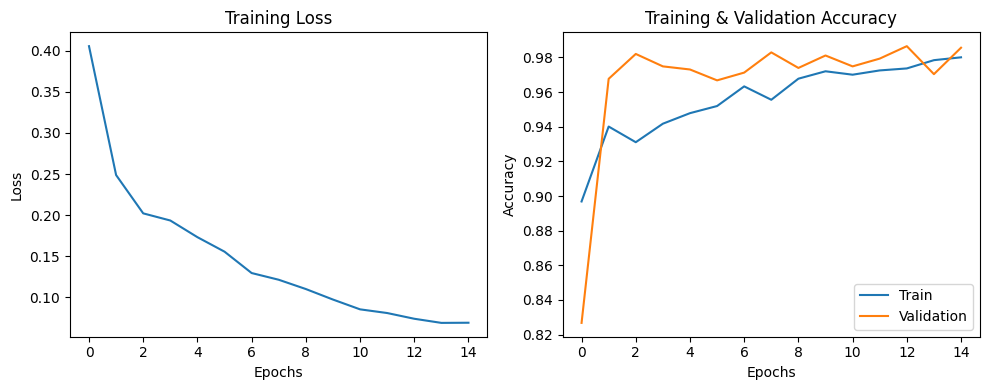


Testing: Hidden=32, Dropout=0.2, Pool=max_mean, LR=0.001
Epoch 1: Loss 0.4144 | Train Acc 0.8529 | Val Acc 0.9614
Epoch 2: Loss 0.2260 | Train Acc 0.9431 | Val Acc 0.9452
Epoch 3: Loss 0.3393 | Train Acc 0.9495 | Val Acc 0.9524
Epoch 4: Loss 0.2020 | Train Acc 0.9426 | Val Acc 0.9605
Epoch 5: Loss 0.1672 | Train Acc 0.9498 | Val Acc 0.9686
Epoch 6: Loss 0.1340 | Train Acc 0.9623 | Val Acc 0.9650
Epoch 7: Loss 0.1860 | Train Acc 0.9396 | Val Acc 0.9856
Epoch 8: Loss 0.1387 | Train Acc 0.9615 | Val Acc 0.9838
Epoch 9: Loss 0.1181 | Train Acc 0.9622 | Val Acc 0.9686
Epoch 10: Loss 0.0987 | Train Acc 0.9737 | Val Acc 0.9794
Epoch 11: Loss 0.0796 | Train Acc 0.9794 | Val Acc 0.9803
Epoch 12: Loss 0.0693 | Train Acc 0.9817 | Val Acc 0.9767
Epoch 13: Loss 0.0631 | Train Acc 0.9766 | Val Acc 0.9794
Epoch 14: Loss 0.0507 | Train Acc 0.9817 | Val Acc 0.9865
Epoch 15: Loss 0.0446 | Train Acc 0.9831 | Val Acc 0.9865


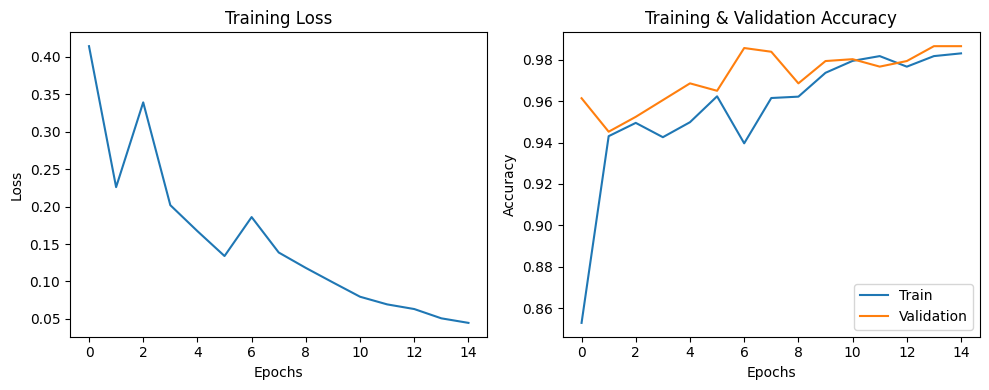


Testing: Hidden=128, Dropout=0.3, Pool=max_mean, LR=0.001
Epoch 1: Loss 0.3769 | Train Acc 0.9291 | Val Acc 0.9668
Epoch 2: Loss 0.2437 | Train Acc 0.9243 | Val Acc 0.9291
Epoch 3: Loss 0.1577 | Train Acc 0.9457 | Val Acc 0.9722
Epoch 4: Loss 0.1293 | Train Acc 0.9592 | Val Acc 0.9811
Epoch 5: Loss 0.1084 | Train Acc 0.9717 | Val Acc 0.9785
Epoch 6: Loss 0.0938 | Train Acc 0.9579 | Val Acc 0.9856
Epoch 7: Loss 0.0798 | Train Acc 0.9834 | Val Acc 0.9829
Epoch 8: Loss 0.0625 | Train Acc 0.9854 | Val Acc 0.9794
Epoch 9: Loss 0.0477 | Train Acc 0.9831 | Val Acc 0.9713
Epoch 10: Loss 0.0356 | Train Acc 0.9888 | Val Acc 0.9749
Epoch 11: Loss 0.0348 | Train Acc 0.9896 | Val Acc 0.9865
Epoch 12: Loss 0.0243 | Train Acc 0.9957 | Val Acc 0.9803
Epoch 13: Loss 0.0190 | Train Acc 0.9847 | Val Acc 0.9856
Epoch 14: Loss 0.0220 | Train Acc 0.9969 | Val Acc 0.9829
Epoch 15: Loss 0.0152 | Train Acc 0.9877 | Val Acc 0.9847


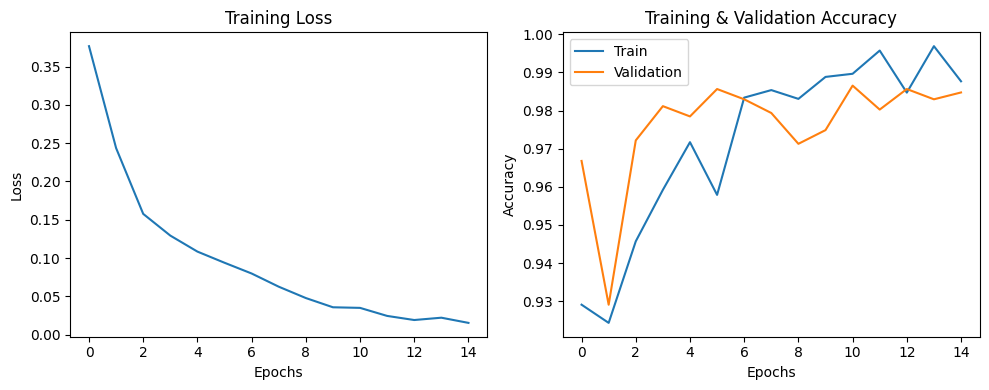


Testing: Hidden=64, Dropout=0.0, Pool=last, LR=0.001
Epoch 1: Loss 0.6866 | Train Acc 0.7393 | Val Acc 0.7819
Epoch 2: Loss 0.6685 | Train Acc 0.7325 | Val Acc 0.7890
Epoch 3: Loss 0.6208 | Train Acc 0.8235 | Val Acc 0.9147
Epoch 4: Loss 0.5450 | Train Acc 0.5323 | Val Acc 0.1302
Epoch 5: Loss 0.6761 | Train Acc 0.6348 | Val Acc 0.8770
Epoch 6: Loss 0.6807 | Train Acc 0.5024 | Val Acc 0.8815
Epoch 7: Loss 0.6844 | Train Acc 0.7653 | Val Acc 0.8528
Epoch 8: Loss 0.6321 | Train Acc 0.8284 | Val Acc 0.8618
Epoch 9: Loss 0.3134 | Train Acc 0.9362 | Val Acc 0.9345
Epoch 10: Loss 0.2588 | Train Acc 0.9380 | Val Acc 0.9704
Epoch 11: Loss 0.3109 | Train Acc 0.7801 | Val Acc 0.9497
Epoch 12: Loss 0.2484 | Train Acc 0.9465 | Val Acc 0.9542
Epoch 13: Loss 0.1889 | Train Acc 0.9477 | Val Acc 0.9731
Epoch 14: Loss 0.1546 | Train Acc 0.9511 | Val Acc 0.9749
Epoch 15: Loss 0.1468 | Train Acc 0.9503 | Val Acc 0.9758


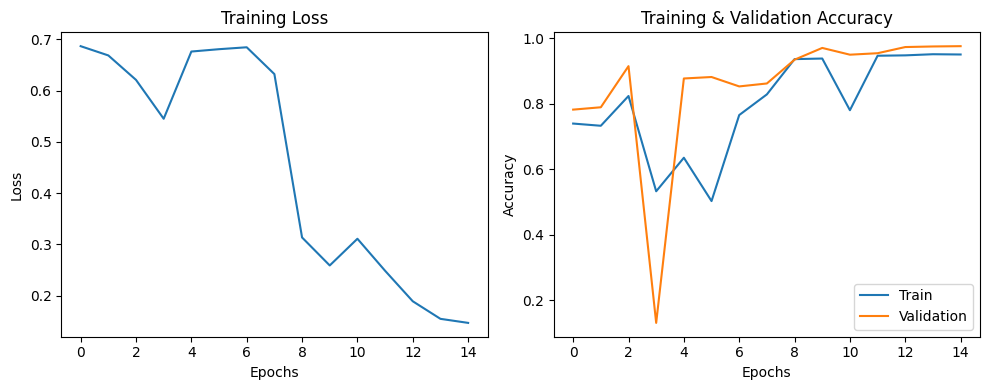

TUNING SUMMARY:

Config (64, 0.0, 'max_mean', 0.001): Best Val Acc = 0.9865350089766607
Config (32, 0.2, 'max_mean', 0.001): Best Val Acc = 0.9865350089766607
Config (128, 0.3, 'max_mean', 0.001): Best Val Acc = 0.9865350089766607
Config (64, 0.0, 'last', 0.001): Best Val Acc = 0.9757630161579892


In [ ]:
configs = [
    (64, 0.0, 'max_mean', 0.001), # Baseline (Your current model)
    (32, 0.2, 'max_mean', 0.001), # Smaller hidden + Dropout
    (128, 0.3, 'max_mean', 0.001), # Larger hidden + Higher Dropout
    (64, 0.0, 'last', 0.001) # Baseline but with 'Last' pooling
]

results = []

for h_size, drop, pool_type, lr in configs:
    print(f"Testing: Hidden={h_size}, Dropout={drop}, Pool={pool_type}, LR={lr}")
    model = SpamRNN_Tuning(119, h_size, dropout=drop, pooling=pool_type)
    
    losses, train_accs, val_accs = train_rnn_network(model, train_loader, val_loader, num_epochs=15, learning_rate=lr)
    
    best_val = max(val_accs)
    
    results.append({'config': (h_size, drop, pool_type, lr), 'best_val': best_val})

print("TUNING SUMMARY:\n")
for r in results:
    print(f"Config {r['config']}: Best Val Acc = {r['best_val']}")

Training the champion model...
Epoch 1: Loss 0.5096 | Train Acc 0.8297 | Val Acc 0.8393
Epoch 2: Loss 0.2888 | Train Acc 0.9194 | Val Acc 0.9381
Epoch 3: Loss 0.1676 | Train Acc 0.9510 | Val Acc 0.9847
Epoch 4: Loss 0.1385 | Train Acc 0.9612 | Val Acc 0.9838
Epoch 5: Loss 0.1177 | Train Acc 0.9717 | Val Acc 0.9820
Epoch 6: Loss 0.1038 | Train Acc 0.9737 | Val Acc 0.9847
Epoch 7: Loss 0.0943 | Train Acc 0.9666 | Val Acc 0.9883
Epoch 8: Loss 0.0855 | Train Acc 0.9653 | Val Acc 0.9874
Epoch 9: Loss 0.0822 | Train Acc 0.9780 | Val Acc 0.9785
Epoch 10: Loss 0.0832 | Train Acc 0.9812 | Val Acc 0.9865
Epoch 11: Loss 0.0723 | Train Acc 0.9796 | Val Acc 0.9838
Epoch 12: Loss 0.0723 | Train Acc 0.9824 | Val Acc 0.9829
Epoch 13: Loss 0.0587 | Train Acc 0.9686 | Val Acc 0.9892
Epoch 14: Loss 0.0581 | Train Acc 0.9832 | Val Acc 0.9865
Epoch 15: Loss 0.0618 | Train Acc 0.9817 | Val Acc 0.9838


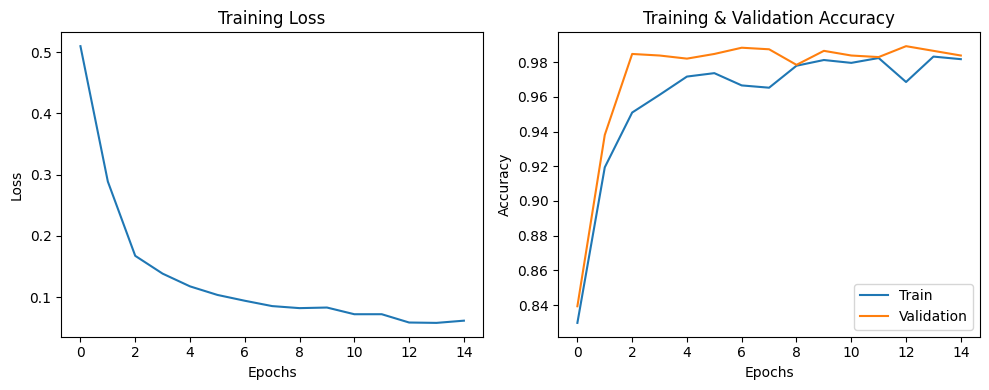

Results for Trained Model

False Positive Rate (FPR): 0.0133
False Negative Rate (FNR): 0.0376


In [ ]:
def get_error_rates(model, data_loader):
    model.eval()
    fp = 0  
    fn = 0  
    total_ham = 0
    total_spam = 0
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for sequences, labels in data_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            outputs = model(sequences)
            preds = outputs.max(1)[1]
            
            for i in range(len(labels)):

                # Actual Ham
                if labels[i] == 0: 
                    total_ham += 1

                    # Predicted Spam
                    if preds[i] == 1: 
                        fp += 1
                
                # Actual Spam
                else: 
                    total_spam += 1
                    
                    # Predicted Ham
                    if preds[i] == 0: 
                        fn += 1
                        
    fpr = fp / total_ham if total_ham > 0 else 0
    fnr = fn / total_spam if total_spam > 0 else 0
    
    return fpr, fnr

best_h, best_d, best_p, best_lr = (32, 0.2, 'max_mean', 0.001)
best_model = SpamRNN_Tuning(vocab_size=119, hidden_size=best_h, dropout=best_d, pooling=best_p)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

print("Training the champion model...")
train_rnn_network(best_model, train_loader, val_loader, num_epochs=15, learning_rate=best_lr)

fpr, fnr = get_error_rates(best_model, val_loader)

print(f"Results for Trained Model\n")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

In [18]:
print(train_y.count(1))
print(train_y.count(0))

3192
2887


### Evaluation

In [19]:
final_test_accuracy = get_accuracy(best_model, test_loader)

print(f"Final Test Accuracy: {final_test_accuracy:.4f}")
print(f"Final Test Accuracy (Percentage): {final_test_accuracy*100:.2f}%")

Final Test Accuracy: 0.9785
Final Test Accuracy (Percentage): 97.85%


In [20]:
test_fpr, test_fnr = get_error_rates(best_model, test_loader)

print(f"Test False Positive Rate (FPR): {test_fpr:.4f} ({test_fpr*100:.2f}%)")
print(f"Test False Negative Rate (FNR): {test_fnr:.4f} ({test_fnr*100:.2f}%)")

Test False Positive Rate (FPR): 0.0157 (1.57%)
Test False Negative Rate (FNR): 0.0570 (5.70%)


In [21]:
message = "machine learning is sooo cool!"

# Convert to indices using stoi dictionary
encoded_msg = [stoi[char] for char in message if char in stoi]

# Convert to tensor and add batch dimension
input_tensor = torch.tensor(encoded_msg).unsqueeze(0)

best_model.eval()
with torch.no_grad():
    logits = best_model(input_tensor)
    probs = torch.softmax(logits, dim=1)

spam_prob = probs[0][1].item()

print(f"Message: '{message}'")
print(f"Probability of being Spam: {spam_prob:.6f}")
print(f"Probability of being Ham: {probs[0][0].item():.6f}")

Message: 'machine learning is sooo cool!'
Probability of being Spam: 0.786885
Probability of being Ham: 0.213115
